# Updating a Model from Plant Data

`28_data_reconciliation.ipynb` adjusted **measurements** to satisfy a model taken as
correct. This notebook asks the opposite question: what if the *model* is the thing
that has drifted?

Both are the same optimisation. A variable with a finite $\sigma$ is a measurement ---
you may move it, at a cost of $(x-y)^2/\sigma^2$. A variable with $\sigma = \infty$ is a
parameter --- move it freely, no cost. That single switch turns reconciliation into
estimation, so the interesting question is not *how* to update a model but **when you
are entitled to**.

The answer matters, because a free parameter can absorb a broken sensor and hand you a
confident, wrong number.

**What this notebook covers**

1. A pipe that fouls slowly while nobody is looking
2. Monitoring with the model held fixed --- the drift shows up in $\chi^2$
3. Telling a model fault from an instrument fault (the global test cannot; something else can)
4. Updating the parameter, and checking the update
5. Why you should *not* leave the parameter free all the time
6. Practical guidance

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import difflow_gas as dg
from difflow_gas import verify
from difflow.reconciliation import global_test, measurement_test

# palette: categorical slots 1-2, plus the reserved "critical" status step
BLUE, ORANGE, RED, GREY = "#2a78d6", "#eb6834", "#d03b3b", "#8a8985"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#eceae6"

def tidy(ax, axis="y"):
    """Recessive axes and grid, so the data carries the emphasis."""
    ax.spines[["top", "right"]].set_visible(False)
    for s in ax.spines.values():
        s.set_color("#d5d4d0")
    ax.tick_params(colors=INK_SOFT, labelsize=8, length=3)
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

RATIOS = {"cs1": 1.2}
P_SLACK_PA = 60.0e5

## 2. The plant and the model

Same five-node network as notebook 28. Pipe `p3` is the long leg of the `b-c-d` loop,
and it is the one that will foul: its effective resistance climbs above the design
value as deposits build up.

The *model* always believes `p3` is clean. The *plant* knows better.

In [2]:
def gas_network(eta_p3=1.0):
    """The network, with p3's resistance scaled by eta_p3 (>1 = fouled)."""
    return dg.GasNetwork(
        arcs={
            "p1":  ("src", "a", "pipe"),
            "cs1": ("a",   "b", "compressor"),
            "p2":  ("b",   "c", "pipe"),
            "p3":  ("b",   "d", "pipe"),
            "p4":  ("c",   "d", "pipe"),
        },
        beta={
            aid: dg.weymouth_beta(length_m=L, diameter_m=0.6, roughness_m=1e-4)
                 * (eta_p3 if aid == "p3" else 1.0)
            for aid, L in [("p1", 20e3), ("p2", 40e3), ("p3", 60e3), ("p4", 80e3)]
        },
        supply_kg_s={"src": 120.0, "c": -50.0, "d": -70.0},
    )

def plant_state(eta_p3):
    """The true pressures and flows of a plant whose p3 is fouled by eta_p3."""
    net = gas_network(eta_p3)
    fs, dec = dg.build_network_flowsheet(
        net, root="src", p_slack_pa=P_SLACK_PA, ratios=RATIOS
    )
    streams = fs.solve(tol=1e-12, max_iter=500)
    return (verify.node_pressures_bar(streams, dec),
            verify.arc_flows_kg_s(streams, dec))

model = gas_network(1.0)                     # what the engineers believe
layout = dg.gas_state_layout(model)
sigma = dg.measurement_sigma(layout)         # every variable metered

p0, q0 = plant_state(1.0)
print("clean-plant flows (kg/s):", {k: round(v, 2) for k, v in q0.items()})

clean-plant flows (kg/s): {'p1': 120.0, 'cs1': 120.0, 'p2': 64.61, 'p3': 55.39, 'p4': 14.61}


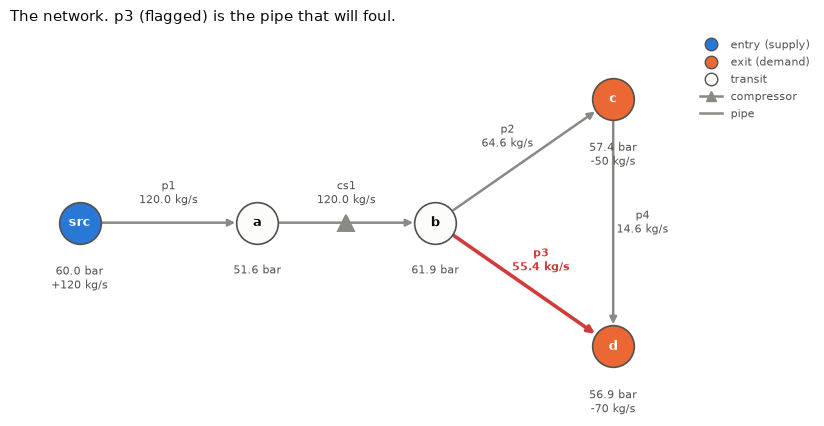

In [3]:
POS = {"src": (0, 0), "a": (1.15, 0), "b": (2.3, 0),
       "c": (3.45, 0.8), "d": (3.45, -0.8)}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
dg.draw_network(
    model, ax=ax, pos=POS, pressures=p0, flows=q0, highlight=["p3"],
    title="The network. p3 (flagged) is the pipe that will foul.",
)
plt.tight_layout()
plt.show()

## 3. Sixty days of operation

Fouling begins on day 12 and grows steadily to 30% excess resistance. Nobody
measures it; the only evidence is that the meters stop agreeing with the model.

For contrast we also simulate a second plant where nothing fouls, but the `p2` flow
meter picks up a $6\sigma$ bias on day 30. Both faults will push $\chi^2$ up by a
similar amount --- which is exactly the difficulty.

In [4]:
DAYS = 45
FOUL_START = 12

eta_true = np.clip(
    1.0 + 0.30 * (np.arange(DAYS) - FOUL_START) / (DAYS - 1 - FOUL_START), 1.0, None
)

# solve the plant once per distinct fouling level, then reuse
levels = {e: plant_state(float(e)) for e in np.unique(np.round(eta_true, 4))}
x_true = {e: layout.pack(p, q, model.supply_kg_s) for e, (p, q) in levels.items()}
print(f"{len(levels)} distinct plant states solved")

33 distinct plant states solved


In [5]:
def simulate(scenario):
    """One day's measurements for each day of the campaign."""
    out = []
    for day in range(DAYS):
        if scenario == "fouling":
            xt = x_true[float(np.round(eta_true[day], 4))]
            gross = None
        else:                                    # clean pipe, bad p2 meter
            xt = x_true[1.0]
            gross = {"q_p2": 6.0} if day >= 30 else None
        out.append(dg.perturb(xt, sigma, jax.random.PRNGKey(1000 + day),
                              layout=layout, gross_errors=gross))
    return out

def monitor(measurements, net):
    """Reconcile each day against a FIXED model; record the diagnostics."""
    chi, suspects = [], []
    for y in measurements:
        res = dg.reconcile_network(net, y, sigma, layout, ratios=RATIOS)
        chi.append(global_test(res).statistic)
        suspects.append(measurement_test(res).suspect)
    return np.array(chi), suspects

data_foul = simulate("fouling")
data_sens = simulate("sensor")

chi_foul, susp_foul = monitor(data_foul, model)
chi_sens, susp_sens = monitor(data_sens, model)

CRIT = global_test(
    dg.reconcile_network(model, data_foul[0], sigma, layout, ratios=RATIOS)
).critical
print(f"reject above chi2 = {CRIT:.2f}")
print(f"last 10 days -- fouling: {chi_foul[-10:].mean():.1f}, "
      f"sensor fault: {chi_sens[-10:].mean():.1f}")

reject above chi2 = 18.31
last 10 days -- fouling: 37.8, sensor fault: 42.3


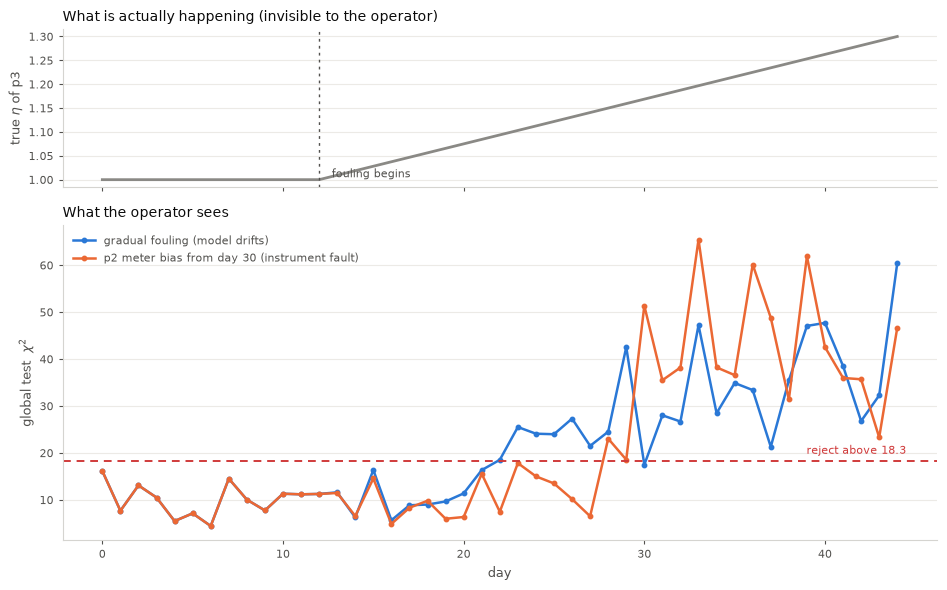

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2]})

ax = axes[0]
ax.plot(eta_true, color=GREY, linewidth=2)
ax.set_ylabel("true $\\eta$ of p3", fontsize=9, color=INK_SOFT)
ax.set_title("What is actually happening (invisible to the operator)",
             fontsize=10, color=INK, loc="left")
ax.axvline(FOUL_START, color=INK_SOFT, linestyle=(0, (2, 3)), linewidth=1)
ax.text(FOUL_START + 0.7, 1.005, "fouling begins", fontsize=8, color=INK_SOFT)
tidy(ax)

ax = axes[1]
ax.plot(chi_foul, color=BLUE, linewidth=1.8, marker="o", markersize=3.2,
        label="gradual fouling (model drifts)")
ax.plot(chi_sens, color=ORANGE, linewidth=1.8, marker="o", markersize=3.2,
        label="p2 meter bias from day 30 (instrument fault)")
ax.axhline(CRIT, color=RED, linestyle=(0, (4, 3)), linewidth=1.4)
ax.text(DAYS - 0.5, CRIT + 1.5, f"reject above {CRIT:.1f}", fontsize=8,
        color=RED, ha="right")
ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
ax.set_ylabel("global test  $\\chi^2$", fontsize=9, color=INK_SOFT)
ax.set_title("What the operator sees", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper left", labelcolor=INK_SOFT)
tidy(ax)

plt.tight_layout()
plt.show()

Both faults raise $\chi^2$ through the threshold, and by the end of the campaign they
raise it by a *similar* amount. The global test says "your data and your model
disagree." It cannot say which of the two is at fault --- it never could, because it
only measures the size of the disagreement.

## 4. Telling a model fault from an instrument fault

The measurement test can, but not from any single day. Look at **which** sensor it
blames, day after day.

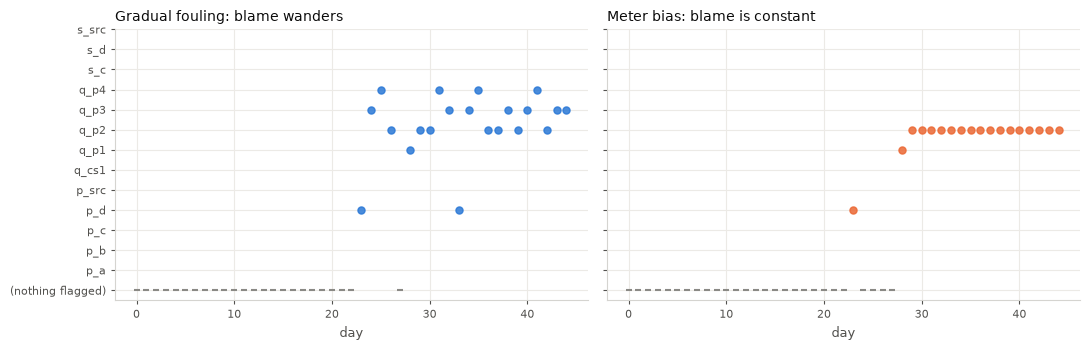

blame concentration, last 15 days
  gradual fouling : 40%
  meter bias      : 100%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
order = layout.names

for ax, susp, title, colour in [
    (axes[0], susp_foul, "Gradual fouling: blame wanders", BLUE),
    (axes[1], susp_sens, "Meter bias: blame is constant", ORANGE),
]:
    days = [d for d, s in enumerate(susp) if s is not None]
    rows = [order.index(susp[d]) for d in days]
    ax.scatter(days, rows, s=26, color=colour, alpha=0.85)
    none_days = [d for d, s in enumerate(susp) if s is None]
    ax.scatter(none_days, [-1] * len(none_days), s=20, color=GREY, marker="_")
    ax.set_yticks(range(-1, len(order)))
    ax.set_yticklabels(["(nothing flagged)"] + order, fontsize=7.5)
    ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
    ax.set_title(title, fontsize=10, color=INK, loc="left")
    tidy(ax, axis="both")

plt.tight_layout()
plt.show()

def blame_concentration(susp, window=15):
    """Fraction of the last `window` days blaming the single most-blamed sensor."""
    tail = [s for s in susp[-window:] if s is not None]
    if not tail:
        return 0.0
    return max(tail.count(s) for s in set(tail)) / window

print(f"blame concentration, last 15 days")
print(f"  gradual fouling : {blame_concentration(susp_foul):.0%}")
print(f"  meter bias      : {blame_concentration(susp_sens):.0%}")

That is the diagnostic. A broken instrument is blamed by name, every day, because the
bias sits on one variable and the redundancy points straight at it. A drifting model
produces a mismatch the adjustments spread around, so the prime suspect keeps changing
and on some days nothing crosses the threshold at all.

**Rule of thumb:** persistent rejection with a *concentrated* suspect is an instrument
problem --- go and calibrate it. Persistent rejection with a *diffuse* suspect is a
model problem --- and only then are you entitled to update a parameter.

## 5. Updating the parameter

Now, and only now, let $\eta$ float. Estimating it from a single day would inherit that
day's noise, so average over a window.

In [8]:
layout_eta = dg.gas_state_layout(model, efficiency_arcs=["p3"])
sigma_eta = dg.measurement_sigma(layout_eta)      # eta defaults to unmeasured

WINDOW = 10
estimates = []
for y in data_foul[-WINDOW:]:
    # re-pack the day's measurements into the layout that carries eta
    y_eta = jnp.concatenate([y, jnp.array([jnp.nan])])
    res = dg.reconcile_network(model, y_eta, sigma_eta, layout_eta, ratios=RATIOS)
    estimates.append((res.x_named["eta_p3"], res.std["eta_p3"]))

eta_hat = float(np.mean([e for e, _ in estimates]))
spread = float(np.std([e for e, _ in estimates]))
per_day_sd = float(np.mean([s for _, s in estimates]))

# eta is still climbing, so the window average estimates the window's
# average truth -- not the final day's value
print(f"eta estimated over the last {WINDOW} days : {eta_hat:.4f}")
print(f"  spread across those days               : {spread:.4f}")
print(f"  reported sd of a single day            : {per_day_sd:.4f}")
print(f"  true mean over the same window         : {eta_true[-WINDOW:].mean():.4f}")
print(f"  true value on the final day            : {eta_true[-1]:.4f}")

eta estimated over the last 10 days : 1.2654
  spread across those days               : 0.0610
  reported sd of a single day            : 0.0551
  true mean over the same window         : 1.2578
  true value on the final day            : 1.3000


Two things to read here. The day-to-day spread and the single-day standard error agree,
which is the check that the uncertainty is honest --- a spread much larger than the
reported $\sigma$ would mean the model is missing a source of variation.

And the estimate tracks the window's *average* truth, not the final day's. Averaging
buys precision at the price of lag, which is unavoidable while the parameter is still
moving: any estimate of a drifting quantity is a statement about the recent past.

Update the model and re-run the last stretch of the campaign against it.

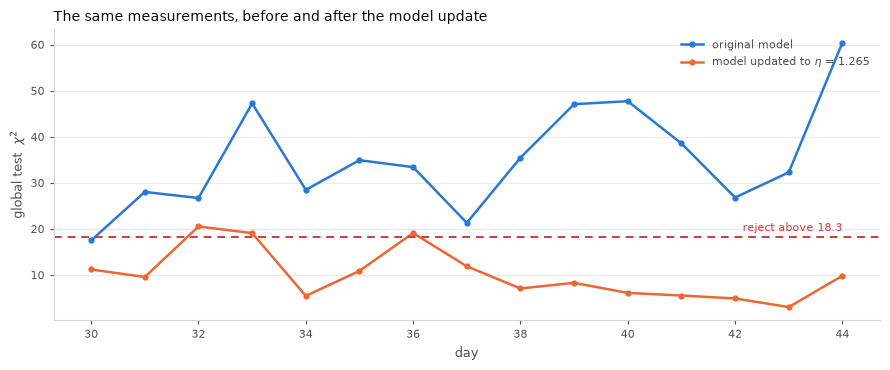

mean chi2  before  35.04   after  10.15   (expected ~10 on 10 dof if the model is right)


In [9]:
updated = gas_network(eta_hat)          # the model, corrected

TAIL = 15
chi_before, _ = monitor(data_foul[-TAIL:], model)
chi_after, _ = monitor(data_foul[-TAIL:], updated)

days = np.arange(DAYS - TAIL, DAYS)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(days, chi_before, color=BLUE, linewidth=1.8, marker="o", markersize=3.5,
        label="original model")
ax.plot(days, chi_after, color=ORANGE, linewidth=1.8, marker="o", markersize=3.5,
        label=f"model updated to $\\eta$ = {eta_hat:.3f}")
ax.axhline(CRIT, color=RED, linestyle=(0, (4, 3)), linewidth=1.4)
ax.text(days[-1], CRIT + 1.2, f"reject above {CRIT:.1f}", fontsize=8, color=RED,
        ha="right")
ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
ax.set_ylabel("global test  $\\chi^2$", fontsize=9, color=INK_SOFT)
ax.set_title("The same measurements, before and after the model update",
             fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper right", labelcolor=INK_SOFT)
tidy(ax)
plt.tight_layout()
plt.show()

print(f"mean chi2  before {chi_before.mean():6.2f}   after {chi_after.mean():6.2f}"
      f"   (expected ~{int(round(np.mean(chi_after)))} on {global_test(dg.reconcile_network(model, data_foul[-1], sigma, layout, ratios=RATIOS)).dof} dof if the model is right)")

The same data that rejected the old model is unremarkable against the updated one.
Nothing about the measurements changed --- only what we now believe about the pipe.

A couple of days still brush the threshold, and that is the lag above showing up: by the
final day the pipe is dirtier than the window average the estimate was built from. It is
the signal that the next update is already due.

One caveat worth being explicit about: the updated model describes the plant **as it is
now**. Re-run it against day 15's data and it will reject, correctly, because the pipe
really was cleaner then. A parameter update is a statement about the present, not a
retroactive correction, and fouling that keeps progressing will need updating again.

## 6. Why not just leave the parameter free?

If a free $\eta$ fixes a drifting model, why fix it at all? Because a free parameter
absorbs whatever is wrong --- including a lying sensor.

Feed the **instrument-fault** data to a reconciliation with $\eta$ free, and watch it
manufacture a fouling estimate out of a bad meter.

In [10]:
y_bad = data_sens[-1]                          # p2 meter biased, pipe is clean
y_bad_eta = jnp.concatenate([y_bad, jnp.array([jnp.nan])])

fixed = dg.reconcile_network(model, y_bad, sigma, layout, ratios=RATIOS)
free = dg.reconcile_network(model, y_bad_eta, sigma_eta, layout_eta, ratios=RATIOS)

print(f"{'':22} {'chi2':>8} {'verdict':>10} {'suspect':>9} {'eta estimate':>14}")
print("-" * 68)
for tag, res, eta in [("parameter fixed", fixed, None),
                      ("parameter free", free, free.x_named["eta_p3"])]:
    g, m = global_test(res), measurement_test(res)
    print(f"{tag:22} {g.statistic:8.2f} {'REJECT' if g.detected else 'accept':>10} "
          f"{str(m.suspect):>9} {('fixed at 1.000' if eta is None else f'{eta:.3f}'):>14}")

print(f"\nthe pipe is genuinely clean (eta = 1.000)")

                           chi2    verdict   suspect   eta estimate
--------------------------------------------------------------------
parameter fixed           46.67     REJECT      q_p2 fixed at 1.000
parameter free            25.25     REJECT      q_p2          1.221

the pipe is genuinely clean (eta = 1.000)


With $\eta$ free the statistic falls, because the parameter has soaked up part of the
bias --- and the fouling estimate it reports is not 1.0. A single meter fault has been
converted into a confident statement about a pipe nobody inspected.

That is the whole argument for the two-clock discipline below. In the routine loop the
model has no freedom, so the $\chi^2$ test is a genuine instrument-health monitor. Give
the model freedom and you trade that monitor away for a number that always looks fine.

## Summary

| | Data reconciliation | Parameter estimation |
|---|---|---|
| What moves | the measurements | the model coefficients |
| In code | finite `sigma` | `sigma = inf` |
| Assumes | model right, sensors wrong | sensors right, model wrong |
| Costs | nothing | one degree of redundancy each |

They are one optimisation, separated only by which weights you set to zero. What
separates them in *practice* is the discipline about when each is allowed to run.

**Two clocks**

- **Routine (hourly, daily): parameters fixed.** The $\chi^2$ test is then a real
  instrument-health monitor, because the model cannot flex to hide a fault.
- **Campaign (weekly, monthly): re-estimate parameters.** Trigger it on *persistent
  rejection with a diffuse suspect* --- the signature of a model fault, section 4 ---
  never on a single bad day, and never on a concentrated suspect, which means go
  calibrate a meter instead.

**Reading the two tests together**

| $\chi^2$ | suspect | reading |
|---|---|---|
| accept | — | healthy |
| reject once | any | noise, or a transient; wait |
| reject persistently | same name every day | instrument fault --- calibrate it |
| reject persistently | wanders, often none | model drift --- estimate the parameter |

**What the differentiability bought here:** the parameter update is not a separate
fitting code path. It is the same `reconcile` call with one `sigma` set to infinity,
and the standard error on $\eta$ comes from the same covariance matrix as every
reconciled flow.